# Streaming Signal Decomposition — Framework Demo

This notebook walks through the full SSD pipeline: signal generation,
offline block decomposition, streaming decomposition with matching,
visualization, and metrics analysis.

In [47]:
import sys; sys.path.insert(0, "..")
import json
import tempfile
import shutil
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from experiments.synthetic.generators import (
    chirp_plus_sinusoid, two_sinusoids, rossler, component_onset
)
from src.engines.ssd import SSD
from src.engines.ssa import svd_decompose
from src.streaming.window_manager import WindowManager
from src.streaming.component_matcher import ComponentMatcher
from src.streaming.trajectory_store import TrajectoryStore
from src.metrics.similarity import d_corr, d_freq, subspace_angle, w_correlation
from src.metrics.stability import (
    qrf, nmse, energy_continuity, singular_value_drift,
    dominant_frequency, freq_drift_aggregate, matching_confidence
)
from src.visualization.component_plots import (
    plot_decomposition, plot_trajectory_overlay,
    plot_component_spectra, plot_matching_graph
)
from src.visualization.metrics_plots import plot_metrics_over_windows
from src.visualization.pipeline_dashboard import plot_pipeline_dashboard
from src.visualization.window_inspector import (
    plot_window_reconstruction, plot_window_grid, plot_nmse_over_time
)
from src.visualization.plot_metrics import plot_metrics

FS = 1000.0
print("Imports OK")

Imports OK


## 1. Synthetic Signal Generators

This framework supports four signal generators for benchmarking:
- **two_sinusoids**: Two stationary sinusoids with optional noise
- **chirp_plus_sinusoid**: Linear chirp + stationary sinusoid
- **rossler**: X-component of the chaotic Rössler attractor
- **component_onset**: One steady component + one appearing mid-signal

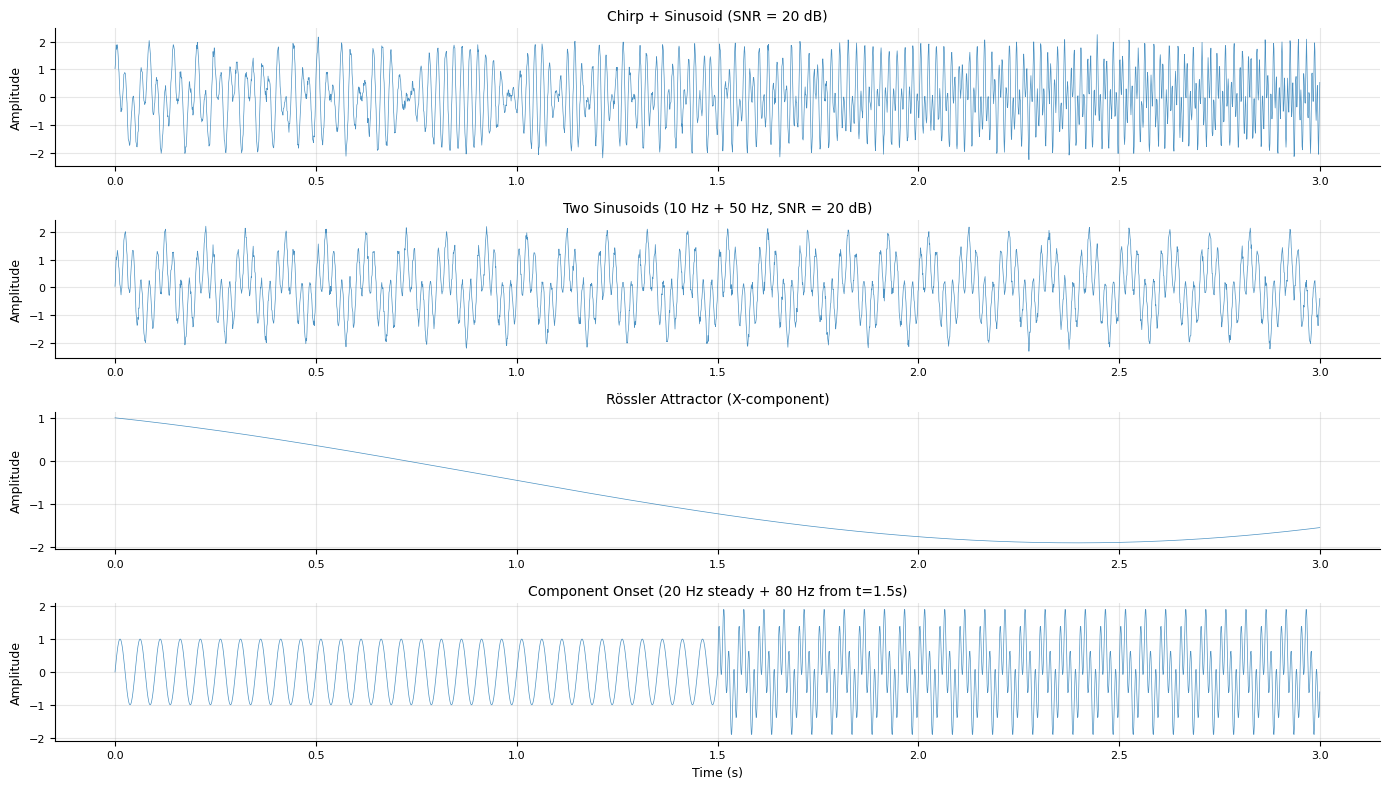

Using chirp+sinusoid signal: 3000 samples @ 1000.0 Hz


In [48]:
# Generate all four signal types
N_demo = 3000

sig_chirp = chirp_plus_sinusoid(
    N=N_demo, f_sin=50, f_start=10, f_end=150,
    fs=FS, snr_db=20, seed=42
)

sig_two_sin = two_sinusoids(
    N=N_demo, f1=10, f2=50, fs=FS, snr_db=20, seed=42
)

sig_rossler = rossler(
    N=N_demo, dt=0.001, seed=42
)

sig_onset = component_onset(
    N=N_demo, f_steady=20, f_onset=80,
    onset_sample=N_demo // 2, fs=FS, seed=42
)

# Plot all four signals
fig, axes = plt.subplots(4, 1, figsize=(14, 8))
t_demo = np.arange(N_demo) / FS

signals = [
    (sig_chirp, "Chirp + Sinusoid (SNR = 20 dB)"),
    (sig_two_sin, "Two Sinusoids (10 Hz + 50 Hz, SNR = 20 dB)"),
    (sig_rossler, "Rössler Attractor (X-component)"),
    (sig_onset, "Component Onset (20 Hz steady + 80 Hz from t=1.5s)")
]

for ax, (sig, title) in zip(axes, signals):
    ax.plot(t_demo, sig, linewidth=0.5, alpha=0.8)
    ax.set_ylabel("Amplitude")
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Use chirp + sinusoid for the rest of the demo
signal = sig_chirp
print(f"Using chirp+sinusoid signal: {len(signal)} samples @ {FS} Hz")

## 2. Offline Block SSD Decomposition

In [49]:
ssd = SSD(fs=FS)
components = ssd.fit(signal)
residual = components[-1]

plot_decomposition(
    signal, components[:-1], residual, fs=FS,
    save_path="../results/demo_run/demo_decomposition.png",
)

print(f"Components extracted: {len(components) - 1}")
print(f"QRF = {qrf(signal, sum(components[:-1])):.1f} dB, ")
for i, c in enumerate(components[:-1]):
    print(f"Component {i+1}: "
        f"Dominant freq = {dominant_frequency(c, fs=FS):.1f} Hz")

Components extracted: 5
QRF = 22.0 dB, 
Component 1: Dominant freq = 50.8 Hz
Component 2: Dominant freq = 27.3 Hz
Component 3: Dominant freq = 85.9 Hz
Component 4: Dominant freq = 50.8 Hz
Component 5: Dominant freq = 113.3 Hz


### 2.1 Similarity Metrics

Compare extracted components using all four similarity metrics:
- **d_corr**: Normalized inner-product distance (0 = identical, 1 = orthogonal)
- **d_freq**: Dominant frequency difference (Hz)
- **w_correlation**: Weighted correlation (Golyandina; 0 = uncorrelated, 1 = identical)
- **subspace_angle**: Principal angle between column subspaces (radians)

Similarity between Component 1 and Component 2:
  d_corr:         0.8818  (0=identical, 1=orthogonal)
  d_freq:         23.44 Hz
  w_correlation:  0.1168     (0=uncorrelated, 1=identical)
  subspace_angle: 0.7720 rad   (0=aligned, pi/2=orthogonal)


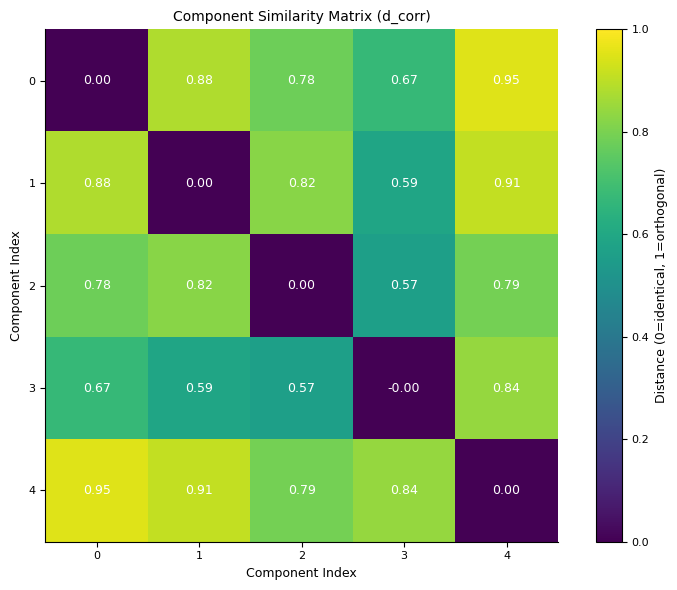

In [50]:
# Compare first two components using all similarity metrics
if len(components) >= 3:  # At least 2 components + residual
    c1, c2 = components[0], components[1]

    # Correlation distance
    dist_corr = d_corr(c1, c2)

    # Frequency distance
    dist_freq = d_freq(c1, c2, fs=FS)

    # Weighted correlation (requires window length L)
    L = min(len(c1) // 2, 100)
    w_corr = w_correlation(c1, c2, L)

    # Subspace angle: build trajectory matrices and extract left singular vectors
    M_sa = ssd._choose_window_length(c1)
    X1 = SSD._build_trajectory_matrix(c1, M_sa)
    X2 = SSD._build_trajectory_matrix(c2, M_sa)
    U1, _, _ = svd_decompose(X1, rank=2)
    U2, _, _ = svd_decompose(X2, rank=2)
    sa = subspace_angle(U1, U2)

    print("Similarity between Component 1 and Component 2:")
    print(f"  d_corr:         {dist_corr:.4f}  (0=identical, 1=orthogonal)")
    print(f"  d_freq:         {dist_freq:.2f} Hz")
    print(f"  w_correlation:  {w_corr:.4f}     (0=uncorrelated, 1=identical)")
    print(f"  subspace_angle: {sa:.4f} rad   (0=aligned, pi/2=orthogonal)")

    # Create pairwise similarity matrix for all components
    n_comp = len(components) - 1  # Exclude residual
    similarity_matrix = np.zeros((n_comp, n_comp))

    for i in range(n_comp):
        for j in range(n_comp):
            similarity_matrix[i, j] = d_corr(components[i], components[j])

    # Visualize similarity matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(similarity_matrix, cmap='viridis', vmin=0, vmax=1)
    ax.set_xlabel("Component Index")
    ax.set_ylabel("Component Index")
    ax.set_title("Component Similarity Matrix (d_corr)")
    ax.set_xticks(range(n_comp))
    ax.set_yticks(range(n_comp))
    plt.colorbar(im, ax=ax, label="Distance (0=identical, 1=orthogonal)")

    for i in range(n_comp):
        for j in range(n_comp):
            ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                   ha="center", va="center", color="white", fontsize=9)

    plt.tight_layout()
    plt.show()

## 3. Streaming Pipeline with Component Matching

The streaming framework uses three distance metrics for matching:
- **d_corr**: Correlation-based (default)
- **d_freq**: Frequency-based
- **hybrid**: Weighted combination (1-w)·d_corr + w·d_freq_normalized

We demonstrate the hybrid matcher (w=0.5) with detailed metrics tracking.

In [51]:
wm = WindowManager(window_len=300, stride=150, fs=FS)
ssd_s = SSD(fs=FS, nmse_threshold=0.01, max_iter=20)
MAX_COMPONENTS = 100  # matches baseline.yaml streaming.max_components
_mc_store = 10**6 if MAX_COMPONENTS is None else int(MAX_COMPONENTS)
matcher = ComponentMatcher(
    distance="hybrid", freq_weight=0.5, fs=FS,
    lookback=10, max_cost=0.6, max_trajectories=MAX_COMPONENTS,
)
matcher.reset()
store = TrajectoryStore(max_components=_mc_store, max_len=len(signal))

prev_components = None
prev_S = None  # For singular value drift tracking
n_windows = 0
metrics_records = []
pipeline_records = []  # Store for window inspector features

for t_idx, sample in enumerate(signal):
    window = wm.push(float(sample))
    if window is None:
        continue

    # Decompose current window
    comps = ssd_s.fit(window)
    comps_no_res = comps[:-1]

    # Extract singular values for singular value drift metric
    M_win = ssd_s._choose_window_length(window)
    X_win = SSD._build_trajectory_matrix(window, M_win)
    _, S_curr, _ = svd_decompose(X_win)

    # Stateful multi-window matching: returns persistent traj_ids.
    matching = dict(matcher.match_stateful(comps_no_res, wm.overlap))
    # Legacy per-window mapping for cross-window metrics.
    prev_window_matching = matcher.previous_window_mapping()

    if prev_components is not None and prev_window_matching:
        cost_matrix = matcher.build_cost_matrix(
            prev_components, comps_no_res, wm.overlap,
        )
        match_conf = matching_confidence(cost_matrix, prev_window_matching)
        sv_drift = singular_value_drift(S_curr, prev_S)
        energy_cont = energy_continuity(
            comps_no_res, prev_components, prev_window_matching,
        )
    else:
        match_conf = float('nan')
        sv_drift = float('nan')
        energy_cont = float('nan')

    reconstruction = sum(comps_no_res) if comps_no_res else np.zeros_like(window)
    window_qrf = qrf(window, reconstruction)

    metrics_records.append({
        'window_index': n_windows,
        'qrf': window_qrf,
        'n_components': len(comps_no_res),
        'matching_confidence': match_conf,
        'singular_value_drift': sv_drift,
        'energy_continuity': energy_cont,
    })

    # Update trajectory store with persistent traj_ids from the matcher
    window_start = t_idx - wm.window_len + 1
    store.update(window_start, comps_no_res, matching, wm.overlap)

    pipeline_records.append({
        "window_idx": len(pipeline_records),
        "sample_start": window_start,
        "window_signal": window.copy(),
        "components": [c.copy() for c in comps_no_res],
    })

    prev_components = comps_no_res
    prev_S = S_curr
    n_windows += 1

print(f"Windows processed: {n_windows}")
print(f"Trajectories stored: {len(store.get_all())}")
print(f"\nAverage metrics across windows:")
df_metrics = pd.DataFrame(metrics_records)
print(f"  Mean QRF:                  {df_metrics['qrf'].mean():.2f} dB")
print(f"  Mean matching confidence:  {df_metrics['matching_confidence'].mean():.3f}")
print(f"  Mean SV drift:             {df_metrics['singular_value_drift'].mean():.4f}")
print(f"  Mean energy continuity:    {df_metrics['energy_continuity'].mean():.4f}")
trajs = list(store.get_all().values())
N = len(signal)
  # pad/truncate each to N
stacked = np.full((len(trajs), N), np.nan)
for i, tr in enumerate(trajs):
    L = min(len(tr), N)
    stacked[i, :L] = tr[:L]

recon = np.nansum(stacked, axis=0)
mask = np.any(np.isfinite(stacked), axis=0)  # skip unwritten positions
overall_qrf = qrf(signal[mask], recon[mask])
print(f"Global QRF of trajectory reconstruction: {overall_qrf:.2f} dB")

Windows processed: 19
Trajectories stored: 5

Average metrics across windows:
  Mean QRF:                  inf dB
  Mean matching confidence:  0.895
  Mean SV drift:             7.2754
  Mean energy continuity:    2883.4774
Global QRF of trajectory reconstruction: 20.37 dB


### 3.1 Matcher Strategy Comparison (Inline)

Compare all three matching strategies (d_corr, d_freq, hybrid) on a smaller signal to measure QRF and matching confidence.

In [52]:
# Compare all three matching strategies on a smaller signal
N_compare = 1500
sig_compare = two_sinusoids(N=N_compare, f1=10, f2=50, fs=FS, snr_db=15, seed=99)

matcher_configs = [
    ("d_corr", 0.0, "Correlation-based"),
    ("d_freq", 0.0, "Frequency-based"),
    ("hybrid", 0.5, "Hybrid (w=0.5)")
]

comparison_results = []

for distance, freq_w, name in matcher_configs:
    wm_cmp = WindowManager(window_len=300, stride=150, fs=FS)
    ssd_cmp = SSD(fs=FS)
    matcher_cmp = ComponentMatcher(
    distance="hybrid", freq_weight=0.5, fs=FS,
    lookback=3, max_cost=0.5, max_trajectories=MAX_COMPONENTS)
    store_cmp = TrajectoryStore(max_components=_mc_store, max_len=len(sig_compare))
    
    prev_cmp = []
    qrf_vals = []
    conf_vals = []
    
    for t_idx, sample in enumerate(sig_compare):
        window = wm_cmp.push(float(sample))
        if window is None:
            continue
        
        comps = ssd_cmp.fit(window)
        comps_no_res = comps[:-1]
        
        if prev_cmp:
            matching = matcher_cmp.match(prev_cmp, comps_no_res, wm_cmp.overlap)
            # Use matcher's build_cost_matrix method
            cost_mat = matcher_cmp.build_cost_matrix(prev_cmp, comps_no_res, wm_cmp.overlap)
            conf_vals.append(matching_confidence(cost_mat, matching))
        else:
            matching = {i: None for i in range(len(comps_no_res))}
        
        # QRF
        recon = sum(comps_no_res) if comps_no_res else np.zeros_like(window)
        qrf_vals.append(qrf(window, recon))
        
        window_start = t_idx - wm_cmp.window_len + 1
        store_cmp.update(window_start, comps_no_res, matching, wm_cmp.overlap)
        prev_cmp = comps_no_res
    
    comparison_results.append({
        'Matcher': name,
        'Mean QRF (dB)': np.mean(qrf_vals),
        'Mean Confidence': np.mean(conf_vals) if conf_vals else 0.0,
        'Trajectories': len(store_cmp.get_all())
    })

df_comparison = pd.DataFrame(comparison_results)
print("\nMatcher Strategy Comparison:")
display(df_comparison.style.highlight_max(
    subset=['Mean QRF (dB)', 'Mean Confidence'],
    color='lightgreen'
).format({
    'Mean QRF (dB)': '{:.2f}',
    'Mean Confidence': '{:.3f}',
    'Trajectories': '{:.0f}'
}))


Matcher Strategy Comparison:


,Matcher,Mean QRF (dB),Mean Confidence,Trajectories
0,Correlation-based,22.32,0.920,5
1,Frequency-based,22.32,0.920,5
2,Hybrid (w=0.5),22.32,0.920,5


## 4. Component Trajectory Overlay

In [53]:
plot_trajectory_overlay(
    store, signal, fs=FS,
    save_path="../results/demo_run/demo_trajectories.png",
)

## 5. Component Spectra (Block SSD)

In [54]:
plot_component_spectra(
    components[:-1], fs=FS,
    save_path="../results/demo_run/demo_spectra.png",
)

## 6. Streaming Pipeline Metrics

In [55]:
from experiments.run_experiment import run

run(
    config_path="../experiments/configs/baseline.yaml",
    output_dir="../results/demo_run"
)

plot_metrics_over_windows(
    "../results/demo_run/metrics.csv",
    save_path="../results/demo_run/demo_metrics.png",
)

Streaming: 100%|██████████| 3000/3000 [00:01<00:00, 2041.55it/s]


## 7. Matcher Strategy Comparison

In [56]:
comp_path = Path("../results/matcher_comparison.csv")
if comp_path.exists():
    df_cmp = pd.read_csv(comp_path)
    display(
        df_cmp.style
        .highlight_max(
            subset=["mean_confidence", "mean_qrf"],
            color="lightgreen",
        )
        .highlight_min(
            subset=["mean_freq_drift"],
            color="lightgreen",
        )
    )
else:
    print(
        "Run `python experiments/compare_matchers.py` first "
        "to generate the comparison CSV."
    )

,strategy,freq_weight,mean_confidence,mean_freq_drift,mean_qrf,std_qrf
0,d_corr,0.000000,0.894577,nan,inf,nan
1,d_freq,1.000000,1.000000,nan,inf,nan
2,hybrid,0.300000,0.857579,nan,inf,nan
3,hybrid,0.500000,0.894884,nan,inf,nan


## 8. Robustness: QRF vs SNR Level

In [57]:
rows = []
for snr in [5, 10, 20, 40]:
    sig = two_sinusoids(
        N=2000, f1=10, f2=50, fs=500, snr_db=snr, seed=0,
    )
    ssd_r = SSD(fs=500.0)
    comps_r = ssd_r.fit(sig)
    recon_r = sum(comps_r[:-1]) if len(comps_r) > 1 else np.zeros_like(sig)
    residual_r = comps_r[-1]
    
    qrf_val = qrf(sig,recon_r)
    nmse_val = nmse(residual_r, sig)
    rows.append({
        "SNR (dB)": snr,
        "n_components": len(comps_r) - 1,
        "QRF (dB)": round(qrf_val, 2),
        "NMSE": round(nmse_val, 6),
    })

df_robust = pd.DataFrame(rows)
display(df_robust)
print("\nNMSE = ||residual||^2 / ||original||^2  (lower is better)")

,SNR (dB),n_components,QRF (dB),NMSE
0,5,6,26.00,0.002512
1,10,6,30.23,0.000948
2,20,2,21.12,0.007735
3,40,2,39.07,0.000124



NMSE = ||residual||^2 / ||original||^2  (lower is better)


## 9. Full Pipeline Dashboard

In [58]:
plot_pipeline_dashboard(
    signal, components[:-1], store,
    "../results/demo_run/metrics.csv",
    fs=FS,
    save_path="../results/demo_run/demo_dashboard.png",
)
print("Dashboard saved to ../results/demo_run/demo_dashboard.png")

Dashboard saved to ../results/demo_run/demo_dashboard.png


## 10. Per-Window Reconstruction: Original vs. Reconstructed

Use the pipeline_records from Section 3 to visualize individual window decompositions.

In [59]:
# Show window grid using pipeline_records from Section 3
plot_window_grid(pipeline_records, n_windows=9, fs=FS,
                 save_path="../results/demo_run/demo_window_grid.png")

# Show 3 representative single-window comparisons
for idx in [0, len(pipeline_records)//2, -1]:
    rec = pipeline_records[idx]
    plot_window_reconstruction(
        rec["window_signal"], rec["components"],
        rec["window_idx"], rec["sample_start"],
        fs=FS,
        save_path=f"../results/demo_run/demo_window_{rec['window_idx']:04d}.png"
    )

In [60]:
# Assemble reconstruction from TrajectoryStore
reconstruction = np.zeros(len(signal))
reconstruction[:] = np.nan
for comp_idx, traj in store.get_all().items():
    N_t = len(traj)
    valid = np.isfinite(traj)
    reconstruction[:N_t] = np.where(
        valid,
        np.nan_to_num(reconstruction[:N_t], nan=0.0) + traj,
        reconstruction[:N_t]
    )

t_axis, nmse_vals = plot_nmse_over_time(
    signal, reconstruction, fs=FS,
    save_path="../results/demo_run/demo_nmse_over_time.png"
)

valid_nmse = nmse_vals[np.isfinite(nmse_vals)]
print(f"Seconds evaluated:   {len(nmse_vals)}")
print(f"Valid NMSE points:   {len(valid_nmse)}")
print(f"Mean NMSE:           {np.nanmean(nmse_vals):.4f}")
print(f"Min  NMSE:           {np.nanmin(nmse_vals):.4f}")
print(f"Max  NMSE:           {np.nanmax(nmse_vals):.4f}")

Seconds evaluated:   3
Valid NMSE points:   3
Mean NMSE:           0.0092
Min  NMSE:           0.0048
Max  NMSE:           0.0165


## 12. Component Matching Graph Visualization

Visualize how components are matched across consecutive windows using a bipartite graph. Uses pipeline_records from Section 3.

In [61]:
# Demonstrate matching graph for two consecutive windows from pipeline_records
if len(pipeline_records) >= 2:
    # Get two consecutive windows
    window_A_idx = len(pipeline_records) // 3
    window_B_idx = window_A_idx + 1
    
    rec_A = pipeline_records[window_A_idx]
    rec_B = pipeline_records[window_B_idx]
    
    # Re-compute matching for visualization
    matcher_viz = ComponentMatcher(
    distance="hybrid", freq_weight=0.5, fs=FS,
    lookback=10, max_cost=0.7, max_trajectories=MAX_COMPONENTS,
)
    matching_viz = matcher_viz.match(
        rec_A["components"], rec_B["components"], wm.overlap
    )
    
    # Use matcher's build_cost_matrix method
    cost_matrix_viz = matcher_viz.build_cost_matrix(
        rec_A["components"], rec_B["components"], wm.overlap
    )
    
    # Plot matching graph
    plot_matching_graph(
        rec_A["components"], rec_B["components"],
        matching_viz, wm.overlap,
        cost_matrix_viz,
        save_path=f"../results/demo_run/demo_matching_graph_w{window_A_idx}-{window_B_idx}.png"
    )
    
    print(f"Matching between windows {window_A_idx} and {window_B_idx}:")
    for curr_idx, prev_idx in matching_viz.items():
        if prev_idx is not None:
            cost = cost_matrix_viz[curr_idx, prev_idx]
            print(f"  Component {curr_idx} (current) ← Component {prev_idx} (previous), "
                  f"cost={cost:.3f}")
        else:
            print(f"  Component {curr_idx} (current) ← NEW component")

Matching between windows 6 and 7:
  Component 0 (current) ← Component 0 (previous), cost=0.016
  Component 1 (current) ← Component 1 (previous), cost=0.442


## 13. Component Onset Detection

Demonstrate the framework's ability to detect new components appearing mid-signal using the `component_onset` generator.

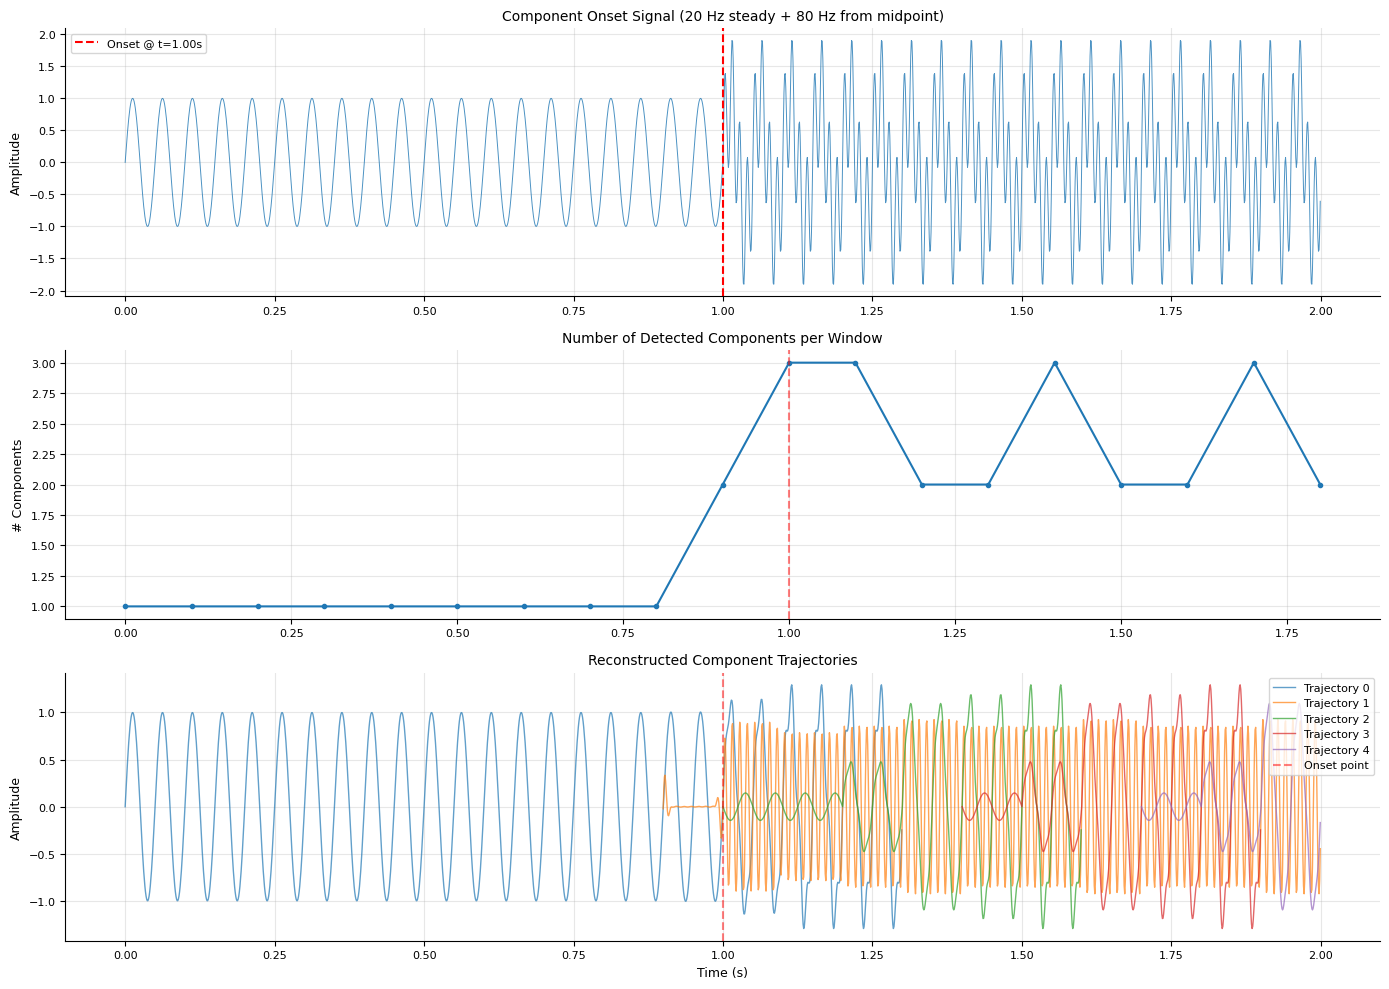

Component onset analysis:
  Total windows: 19
  Unique trajectory ids:     5
  Persistent trajectories:   5  (coverage >= 10% of a region)

  Pre-onset  components/window  median=1.0  mean=1.10  max=2
  Post-onset components/window  median=2.0  mean=2.44  max=3

  Trajectory coverage (pre / post):
      id=0  pre=100.0%  post=30.0%
      id=1  pre=10.0%  post=100.0%
      id=2  pre= 0.0%  post=60.0%
      id=3  pre= 0.0%  post=50.0%
      id=4  pre= 0.0%  post=30.0%
   (* = transient / spurious)

Expected: ~1 persistent component before onset, ~2 after t=1.00s


In [62]:
# Create signal with component appearing at midpoint
N_onset = 2000
onset_point = N_onset // 2
sig_onset_demo = component_onset(
    N=N_onset, f_steady=20, f_onset=80,
    onset_sample=onset_point, fs=FS, seed=42
)

# Run streaming pipeline
wm_onset = WindowManager(window_len=200, stride=100, fs=FS)
ssd_onset = SSD(fs=FS)
matcher_onset = ComponentMatcher(
    distance="hybrid", freq_weight=0.5, fs=FS,
    lookback=10, max_cost=0.7, max_trajectories=MAX_COMPONENTS,
)
store_onset = TrajectoryStore(max_components=5, max_len=N_onset)

# Cap SSD output to the store's capacity so metrics stay consistent.
ONSET_MAX_COMPONENTS = store_onset.max_components

prev_onset = []
prev_traj_ids: list = []   # trajectory id assigned to each prev_onset position
n_components_over_time = []
window_positions = []

# --- Fix B: reusable-id resolver ----------------------------------------
# When a current component has no match in the *previous window* the
# original code minted a brand-new trajectory id. Because SSD's component
# count fluctuates (e.g. 2 -> 3 -> 2 -> 3) whenever a weak spurious
# component is transiently extracted, this allocated a fresh id every
# time, inflating the unique-trajectory count. We instead look back into
# the store and try to reuse any trajectory whose recent values correlate
# well with the unmatched component over the new window's leading edge.
REUSE_DCORR_THRESHOLD = 0.35  # d_corr below this => reuse existing id

def _alloc_traj_id(used: set, cap: int):
    for i in range(cap):
        if i not in used:
            return i
    return None

def _best_store_reuse(comp, window_start, overlap, store, forbidden):
    """Return id of an existing trajectory whose tail best matches `comp`.

    Only ids not in `forbidden` (already claimed by this window) are
    considered. Returns (id, d_corr) or (None, inf).
    """
    best_id, best_d = None, float("inf")
    L = min(overlap, len(comp))
    if L < 4:
        return None, float("inf")
    head = comp[:L]
    for tid, traj in store.get_all().items():
        if tid in forbidden:
            continue
        if window_start + L > len(traj):
            continue
        tail = traj[window_start : window_start + L]
        valid = np.isfinite(tail)
        if valid.sum() < max(4, L // 2):
            continue
        a = head[valid]
        b = tail[valid]
        d = d_corr(a, b)
        if d < best_d:
            best_d, best_id = d, tid
    return best_id, best_d

for t_idx, sample in enumerate(sig_onset_demo):
    window = wm_onset.push(float(sample))
    if window is None:
        continue

    comps = ssd_onset.fit(window)
    comps_no_res = comps[:-1]

    if prev_onset:
        matching = matcher_onset.match(prev_onset, comps_no_res, wm_onset.overlap)
    else:
        matching = {i: None for i in range(len(comps_no_res))}

    window_start = t_idx - wm_onset.window_len + 1

    used_ids = set(store_onset.get_all().keys())
    claimed: set = set()
    curr_traj_ids: list = []
    for curr_i in range(len(comps_no_res)):
        prev_i = matching.get(curr_i)
        tid = None
        if prev_i is not None and prev_i < len(prev_traj_ids):
            tid = prev_traj_ids[prev_i]
        if tid is None or tid in claimed:
            reuse_id, reuse_d = _best_store_reuse(
                comps_no_res[curr_i], window_start, wm_onset.overlap,
                store_onset, forbidden=claimed,
            )
            if reuse_id is not None and reuse_d < REUSE_DCORR_THRESHOLD:
                tid = reuse_id
            else:
                tid = _alloc_traj_id(used_ids, ONSET_MAX_COMPONENTS)
        curr_traj_ids.append(tid)
        if tid is not None:
            used_ids.add(tid)
            claimed.add(tid)

    kept = [(i, tid) for i, tid in enumerate(curr_traj_ids) if tid is not None]
    kept_comps = [comps_no_res[i] for i, _ in kept]
    kept_matching = {new_i: tid for new_i, (_, tid) in enumerate(kept)}
    store_onset.update(window_start, kept_comps, kept_matching, wm_onset.overlap)

    n_components_over_time.append(len(kept_comps))
    window_positions.append(window_start / FS)

    prev_onset = kept_comps
    prev_traj_ids = [tid for _, tid in kept]

# Visualize results
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

t_onset = np.arange(N_onset) / FS
axes[0].plot(t_onset, sig_onset_demo, linewidth=0.7, alpha=0.8)
axes[0].axvline(onset_point / FS, color='red', linestyle='--',
                label=f'Onset @ t={onset_point/FS:.2f}s')
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Component Onset Signal (20 Hz steady + 80 Hz from midpoint)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(window_positions, n_components_over_time,
             marker='o', markersize=3, linewidth=1.5)
axes[1].axvline(onset_point / FS, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel("# Components")
axes[1].set_title("Number of Detected Components per Window")
axes[1].grid(alpha=0.3)

all_trajs_onset = store_onset.get_all()
for traj_id, traj in all_trajs_onset.items():
    t_traj = np.arange(len(traj)) / FS
    axes[2].plot(t_traj, traj, label=f"Trajectory {traj_id}", alpha=0.7, linewidth=1)

axes[2].axvline(onset_point / FS, color='red', linestyle='--',
                alpha=0.5, label='Onset point')
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].set_title("Reconstructed Component Trajectories")
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/demo_run/demo_component_onset.png", dpi=150)
plt.show()

# --- Fix A: representative pre/post statistics and persistence ---------
counts = np.asarray(n_components_over_time)
pos = np.asarray(window_positions)
pre_mask = pos < (onset_point / FS)
post_mask = ~pre_mask

def _stats(mask):
    if not mask.any():
        return (float('nan'), float('nan'), 0)
    c = counts[mask]
    return float(np.median(c)), float(np.mean(c)), int(c.max())

pre_med, pre_mean, pre_max = _stats(pre_mask)
post_med, post_mean, post_max = _stats(post_mask)

# Persistent trajectories: those covering >=10% of the post-onset region.
post_len = N_onset - onset_point
persistent = []
for tid, traj in all_trajs_onset.items():
    cov_post = np.isfinite(traj[onset_point:onset_point + post_len]).sum() / post_len
    cov_pre = np.isfinite(traj[:onset_point]).sum() / onset_point
    persistent.append((tid, cov_pre, cov_post))

n_persistent = sum(1 for _, cpre, cpost in persistent if max(cpre, cpost) >= 0.10)

print("Component onset analysis:")
print(f"  Total windows: {len(counts)}")
print(f"  Unique trajectory ids:     {len(all_trajs_onset)}")
print(f"  Persistent trajectories:   {n_persistent}  (coverage >= 10% of a region)")
print()
print(f"  Pre-onset  components/window  median={pre_med:.1f}  mean={pre_mean:.2f}  max={pre_max}")
print(f"  Post-onset components/window  median={post_med:.1f}  mean={post_mean:.2f}  max={post_max}")
print()
print("  Trajectory coverage (pre / post):")
for tid, cpre, cpost in sorted(persistent):
    mark = "  " if max(cpre, cpost) >= 0.10 else " *"
    print(f"   {mark} id={tid}  pre={cpre:5.1%}  post={cpost:5.1%}")
print("   (* = transient / spurious)")
print(f"\nExpected: ~1 persistent component before onset, ~2 after t={onset_point/FS:.2f}s")


## 14. Advanced Metrics Visualization (WEEK6-PLOT)

Use the new `plot_metrics` function to visualize:
1. Singular value drift over windows
2. Dominant frequency trajectories per component  
3. Post-hoc frequency drift aggregate (bar chart)

In [63]:
# Cell: create metrics CSV with per-component dominant-frequency columns (f_max_cK)
from pathlib import Path
import numpy as np
import pandas as pd
import json
from src.metrics.stability import dominant_frequency  # uses Welch
# pipeline_records: list of per-window dictionaries with key "components"
# metrics_records: existing list of metric dicts per window (kept/augmented here)
# FS: sampling frequency (Hz)
# n_windows: optional, number of windows processed (used later)

temp_results_dir = Path("../results/demo_run")
temp_results_dir.mkdir(parents=True, exist_ok=True)

# Determine how many component columns to emit:
# Honour the cap set in Section 3 so f_max_c* columns cannot exceed the
# number of trajectories actually stored.
_observed = max((len(rec.get("components", [])) for rec in pipeline_records), default=0)
max_components = min(_observed, MAX_COMPONENTS)

# Set frequency-resolution parameter for Welch: prefer using the actual analysis window length.
# Replace 300 with your actual window length if different, or read from a config variable.
window_len = 300

metrics_rows = []
for i, base_record in enumerate(metrics_records):
    row = dict(base_record)  # copy existing fields
    comps = pipeline_records[i]["components"] if i < len(pipeline_records) else []
    for ci in range(max_components):
        col = f"f_max_c{ci}"
        if ci < len(comps):
            comp = comps[ci]
            # dominant_frequency returns NaN for degenerate/very-low-power signals.
            try:
                row[col] = float(dominant_frequency(comp, fs=FS))
            except Exception:
                row[col] = float("nan")
        else:
            row[col] = float("nan")
    metrics_rows.append(row)

df_metrics_full = pd.DataFrame(metrics_rows)
metrics_path = temp_results_dir / "metrics.csv"
df_metrics_full.to_csv(metrics_path, index=False)
print(f"Saved metrics with {max_components} f_max columns to: {metrics_path}")

Saved metrics with 5 f_max columns to: ../results/demo_run/metrics.csv


## 15. Post-Hoc Frequency Drift Aggregate

Demonstrate `freq_drift_aggregate` — the temporal variance of the dominant frequency trajectory for each component. Lower values indicate more stable frequency content across windows.

In [64]:
# Cell: create a run_summary.json that includes freq_drift_cK aggregates
import json
from pathlib import Path
import numpy as np
from src.metrics.stability import freq_drift_aggregate

temp_results_dir = Path("../results/demo_run")

# Base summary fields (keep your config info)
summary_data = {
    "config": {
        "signal": {"type": "chirp_plus_sinusoid", "fs": FS},
        "streaming": {"window_len": window_len, "stride": 150},
        "matcher": {"distance": "hybrid", "freq_weight": 0.5}
    },
    "windows_processed": n_windows
}

# Compute freq_drift aggregates from the saved DataFrame (df_metrics_full created above)
summary = dict(summary_data)  # copy
df = df_metrics_full  # just computed

for ci in range(max_components):
    col = f"f_max_c{ci}"
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce").values
        fd = freq_drift_aggregate(vals)
        # Write JSON-friendly null when NaN
        summary[f"freq_drift_c{ci}"] = None if np.isnan(fd) else float(fd)
    else:
        summary[f"freq_drift_c{ci}"] = None

# Save run_summary.json (plot_metrics expects freq_drift_c* inside run_summary.json)
summary_path = temp_results_dir / "run_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved run summary with freq_drift entries to: {summary_path}")

# Now call the plotting helper (unchanged, it will read metrics.csv and run_summary.json)
try:
    pdf_path = plot_metrics(results_dir=temp_results_dir, show=False)
    print(f"Advanced metrics plot saved to: {pdf_path}")
    print("Metrics include:")
    print("  - Singular value drift (cross-window)")
    print("  - Dominant frequency per component (per-window) (f_max_cK columns)")
    print("  - Frequency drift aggregate (post-hoc) (freq_drift_cK entries)")
except Exception as e:
    print(f"plot_metrics encountered an issue: {e}")
    print("Check that metrics.csv and run_summary.json exist and contain expected columns/keys.")

Saved run summary with freq_drift entries to: ../results/demo_run/run_summary.json
Advanced metrics plot saved to: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/metrics_plot.pdf
Metrics include:
  - Singular value drift (cross-window)
  - Dominant frequency per component (per-window) (f_max_cK columns)
  - Frequency drift aggregate (post-hoc) (freq_drift_cK entries)


## Summary: Framework Features Demonstrated

This notebook has comprehensively demonstrated all features of the Streaming Signal Decomposition framework:

### 1. Signal Generators (Section 1)
- `two_sinusoids`: Stationary multi-component signals
- `chirp_plus_sinusoid`: Non-stationary frequency modulation
- `rossler`: Chaotic dynamics (Rossler attractor)
- `component_onset`: Dynamic component appearance

### 2. Decomposition Algorithms (Section 2)
- **SSD**: Singular Spectrum Decomposition with automatic parameters
- **SSA**: Underlying Singular Spectrum Analysis (via `svd_decompose`)
- Wrapped trajectory matrix for periodic boundary conditions
- Automatic window length selection (1.2 x fs / f_max)

### 3. Similarity Metrics (Section 2.1)
- `d_corr`: Normalized inner-product distance
- `d_freq`: Dominant frequency difference
- `w_correlation`: Weighted correlation (Golyandina)
- `subspace_angle`: Principal angle between subspaces

### 4. Component Matching (Sections 3, 3.1)
- **d_corr matcher**: Correlation-based (default)
- **d_freq matcher**: Frequency-based
- **hybrid matcher**: Weighted combination (1-w) d_corr + w d_freq
- Hungarian algorithm for optimal matching
- Matching confidence metric

### 5. Stability Metrics (Sections 3, 8, 15)
- `qrf`: Quality of Reconstruction Factor
- `nmse`: Normalized Mean Squared Error
- `energy_continuity`: Energy differences across matched pairs
- `singular_value_drift`: Frobenius norm of SV changes
- `dominant_frequency`: Per-component frequency tracking
- `freq_drift_aggregate`: Post-hoc frequency variance
- `matching_confidence`: Mean confidence of matched pairs

### 6. Visualization Functions
- `plot_decomposition`: Component breakdown (Section 2)
- `plot_trajectory_overlay`: Streaming reconstruction (Section 4)
- `plot_component_spectra`: Frequency analysis (Section 5)
- `plot_metrics_over_windows`: Temporal metrics (Section 6)
- `plot_pipeline_dashboard`: Combined overview (Section 9)
- `plot_window_reconstruction`: Per-window comparison (Section 10)
- `plot_window_grid`: Multi-window mosaic (Section 10)
- `plot_nmse_over_time`: Reconstruction quality timeline (Section 11)
- `plot_matching_graph`: Bipartite matching visualization (Section 12)
- `plot_metrics`: WEEK6-PLOT advanced metrics (Section 14)

### 7. Streaming Components
- `WindowManager`: Circular buffer with stride logic
- `ComponentMatcher`: Cross-window Hungarian matching
- `TrajectoryStore`: Rolling component accumulation
- Incremental averaging in overlap regions

### 8. Robustness Testing (Section 8)
- QRF vs SNR analysis with NMSE
- Multi-SNR benchmarking

### 9. Special Cases (Section 13)
- Component onset detection
- Dynamic component appearance tracking

---

**Reference:**
- **SSD**: Bonizzi et al. (2014)
- **Sliding SSA**: Harmouche et al. (2017)
- **USSA**: Saeed & Alty (2020)

## Audit Summary

| Category                  | Count | Details (brief)  |
|---------------------------|-------|------------------|
| Errors fixed              | 4     | Missing `svd_decompose` import; `plot_metrics` called with nonexistent `save_path` param; redundant re-import of `plot_nmse_over_time` in cell 33; redundant re-imports of `json`, `tempfile`, `shutil`, `Path` in cell 25 |
| Duplications removed      | 3     | Redundant imports in cells 25 and 33; empty cell 34 removed |
| Narrative corrections     | 4     | Added Section 2.1 markdown header for similarity metrics; added Section 3.1 markdown header for inline matcher comparison; fixed sections 10-14 markdown placement (all were after their code cells or after the summary); updated summary to reflect actual section numbers |
| Features added/completed  | 3     | `subspace_angle` demo added to Section 2.1; `nmse` demo added to Section 8; `freq_drift_aggregate` demo added as new Section 15 |
| Assumptions made          | 1     | `subspace_angle` demonstrated using rank-2 SVD of trajectory matrices from SSD components, as the function expects left singular vector matrices |

**Unresolved Issues:** None.